# Cancer Dataset: Synthetic Data Quality Assessment with Mahalanobis Distance

This notebook:
1. Loads the **Cancer** dataset and prepares it for synthesis.
2. Generates synthetic data using **SDV** models: **CTGAN**, **CopulaGAN**, **Gaussian Copula**, and **TVAE**.
3. Assesses synthetic data quality using **Mahalanobis distance** (distribution-based and optional pairwise/Hungarian matching).

**Mahalanobis distance** measures how far a point is from a distribution in terms of standard deviations, accounting for correlations between features. Lower distances indicate synthetic samples that are closer to the real data distribution.

## 1. Data loading and preparation

In [1]:
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

# Path to Cancer dataset: find project root (folder containing 'Datasets')
import os
cwd = os.getcwd()
candidates = [cwd, os.path.join(cwd, '..'), os.path.join(cwd, '..', '..')]
ROOT = cwd
for c in candidates:
    p = os.path.abspath(c)
    if os.path.isdir(os.path.join(p, 'Datasets')):
        ROOT = p
        break
DATA_PATH = os.path.join(ROOT, "Datasets", "Cancer.csv")

cancer_data = pd.read_csv(DATA_PATH)
cancer_data.drop(['id', 'Unnamed: 32'], axis=1, inplace=True, errors='ignore')
# Use numeric features only for Mahalanobis (drop diagnosis for distance computation)
data = cancer_data.drop(columns=['diagnosis'], errors='ignore')

print(f"Data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.info()

Data shape: (569, 30)
Columns: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    fl

In [2]:
import sdv
from sdv.metadata import SingleTableMetadata

# For SDV we use full table (with diagnosis as numeric for consistency with other notebooks)
cancer_sdv = cancer_data.copy()
cancer_sdv.replace({'diagnosis': {'M': 1, 'B': 0}}, inplace=True)

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(cancer_sdv)

# Numeric-only dataframe for Mahalanobis (same 30 columns as in cosine assessment)
feature_cols = [c for c in data.columns]
data_numeric = data.astype(float)
print(f"Numeric feature matrix shape: {data_numeric.shape}")

Numeric feature matrix shape: (569, 30)


## 2. SDV models: fit and sample

We fit **CTGAN**, **CopulaGAN**, **Gaussian Copula**, and **TVAE** on the full Cancer table (with diagnosis), then sample the same number of rows as the real data. Mahalanobis is computed on the numeric feature columns only.

In [3]:
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

models = {
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata),
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
}

for name, model in models.items():
    print(f"Fitting {name}...")
    model.fit(cancer_sdv)

print("All models fitted!")

Fitting GaussianCopula...
Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...
All models fitted!


In [4]:
# Synthetic sample size = real data sample size (required for one-to-one Hungarian matching)
n_rows = len(cancer_sdv)
synthetic_data = {}

for name, model in models.items():
    synthetic_data[name] = model.sample(num_rows=n_rows)
    # Align columns to numeric features only (drop diagnosis if present for distance)
    synth_numeric = synthetic_data[name][feature_cols].astype(float)
    synthetic_data[name + "_numeric"] = synth_numeric

print(f"Real data size: {n_rows}. Sampled {n_rows} synthetic rows per model (same as real).")
print("Sample (GaussianCopula):")
display(synthetic_data["GaussianCopula"].head())

Real data size: 569. Sampled 569 synthetic rows per model (same as real).
Sample (GaussianCopula):


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,13.063,18.07,82.27,534.0,0.07895,0.04268,0.022739,0.019326,0.1457,...,13.945,25.23,89.44,596.3,0.12997,0.09224,0.102124,0.081370,0.2130,0.07473
1,0,12.903,16.68,83.22,511.3,0.11140,0.13874,0.046816,0.024106,0.2176,...,14.824,25.43,95.36,703.1,0.15198,0.39831,0.219331,0.114531,0.3815,0.10816
2,0,12.144,20.38,79.67,440.2,0.10578,0.15952,0.087810,0.037386,0.2042,...,14.063,31.96,92.47,597.6,0.14872,0.43640,0.252768,0.146417,0.4024,0.10780
3,1,11.171,20.74,71.76,381.8,0.10040,0.08525,0.028174,0.021851,0.1560,...,11.366,27.09,72.87,399.3,0.13801,0.13753,0.049883,0.047761,0.2118,0.07572
4,1,28.110,25.93,188.50,2425.7,0.08694,0.08802,0.138158,0.094686,0.1234,...,36.040,36.42,251.20,3947.7,0.14332,0.26353,0.408867,0.214969,0.1913,0.07765


## 4. Mahalanobis distance: setup

We estimate the **mean** and **covariance** of the real data (numeric features), then compute Mahalanobis distance for each synthetic sample to this distribution:

$$d_M(x) = \sqrt{(x - \mu)^T \Sigma^{-1} (x - \mu)}$$

If the covariance is singular, we add a small regularization (ridge) so that $\Sigma + \lambda I$ is invertible.

In [6]:
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    """
    Compute mean and inverse covariance for Mahalanobis distance.
    real_matrix: (n_samples, n_features) array.
    Returns: mean (1D), inv_cov (2D).
    """
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    # Ensure shape (p,p) when n_samples small
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = inv(cov + (reg * 10) * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    """
    For each row in synth_matrix, compute Mahalanobis distance to distribution (mu, inv_cov).
    Returns 1D array of length synth_matrix.shape[0].
    """
    delta = synth_matrix - mu
    # d_i^2 = (x_i - mu)^T inv_cov (x_i - mu)
    d2 = np.einsum('ij,jk,ik->i', delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0))

# Fit on real data (no scaling)
real_matrix = data_numeric.to_numpy()
mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (30,), Inv_cov shape: (30, 30)


## 5. Quality assessment: Mahalanobis distance per model

For each synthetic dataset we compute the Mahalanobis distance of every synthetic sample to the **real** distribution, then report mean, median, and std. **Lower** values indicate better fidelity to the real distribution.

In [7]:
mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name + "_numeric"].to_numpy()
    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)
    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

# Summary table
summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T
summary.index.name = "Model"
print("Mahalanobis distance to real distribution (lower is better):")
display(summary)

Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
GaussianCopula,6.532506,6.202199,1.902008,3.026164,18.537426
CTGAN,121.272888,107.046578,59.678446,30.054684,353.261794
CopulaGAN,135.940286,122.722440,69.482073,30.427821,329.158040
TVAE,43.938742,33.686949,31.460607,8.068907,181.917915


## 6. Visualization: distribution of Mahalanobis distances

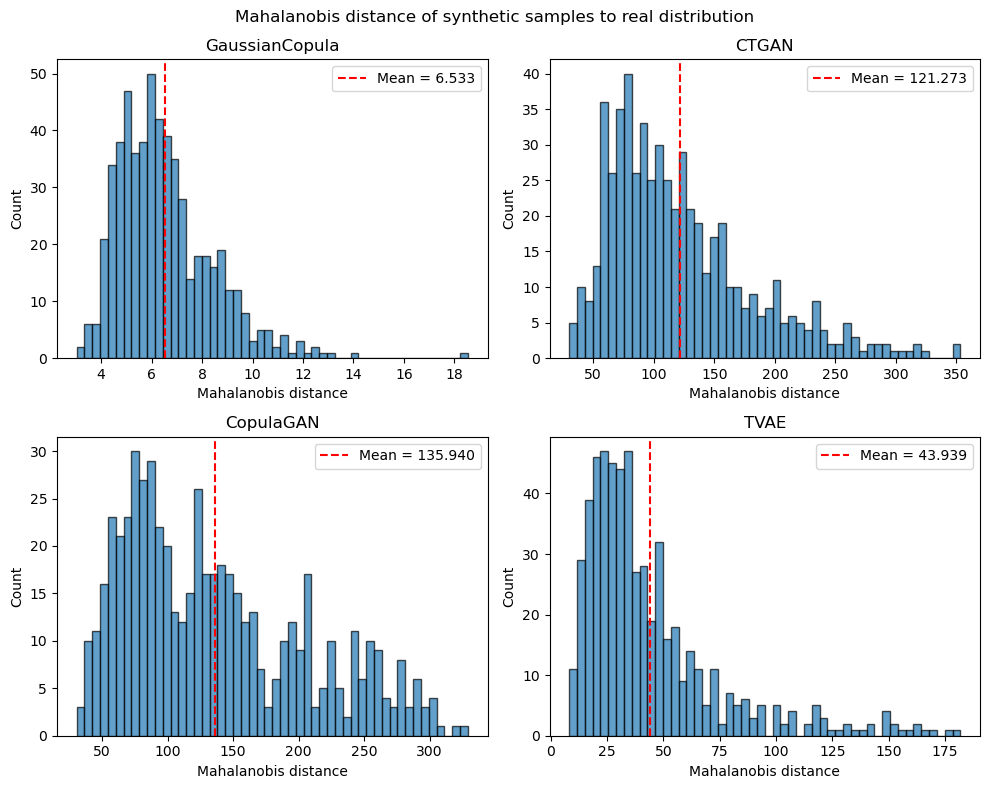

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(res["mean"], color='red', linestyle='--', label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()
plt.suptitle("Mahalanobis distance of synthetic samples to real distribution", fontsize=12)
plt.tight_layout()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(os.path.join(ROOT, "figures", "mahalanobis_cancer_by_model.png"), dpi=150, bbox_inches='tight')
plt.show()

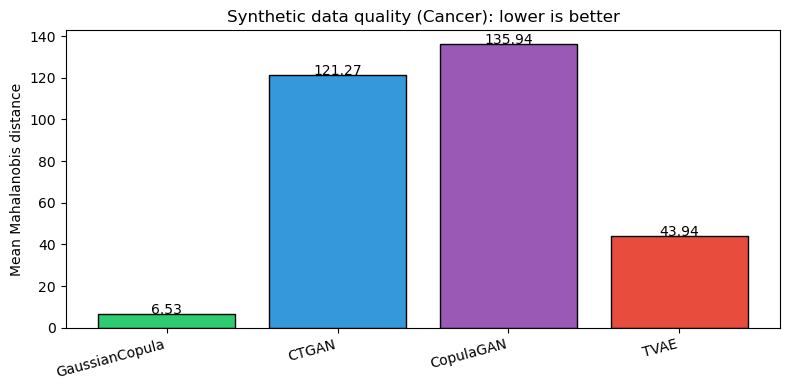

In [9]:
# Bar plot: mean Mahalanobis distance by model
fig, ax = plt.subplots(figsize=(8, 4))
models_order = ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]
means = [mahalanobis_results[m]["mean"] for m in models_order]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars = ax.bar(models_order, means, color=colors, edgecolor='black')
ax.set_ylabel("Mean Mahalanobis distance")
ax.set_title("Synthetic data quality (Cancer): lower is better")
ax.set_xticklabels(models_order, rotation=15, ha='right')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{val:.2f}", ha='center', fontsize=10)
plt.tight_layout()
os.makedirs(os.path.join(ROOT, "Mahalanobis_distance", "Cancer", "figures"), exist_ok=True)
plt.savefig(os.path.join(ROOT, "Mahalanobis_distance", "Cancer", "figures", "mahalanobis_mean_by_model.png"), dpi=150, bbox_inches='tight')
plt.show()

## 7. Hungarian algorithm: optimal one-to-one matching (Mahalanobis as cost)

We treat **Mahalanobis distance** as the cost between each real and each synthetic sample. The **Hungarian algorithm** finds the optimal one-to-one matching that **minimizes total cost** (sum of matched Mahalanobis distances). We report total cost and mean cost per match for each model.

In [10]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    """
    Compute pairwise Mahalanobis distances.
    real_matrix: (n x p)
    synth_matrix: (n x p)
    inv_cov: (p x p) from REAL data
    """
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

In [12]:
# Hungarian matching: use full real and synthetic data (same size n_rows)
hungarian_results = {}

n_samples = len(real_matrix)  # real and synthetic both have this many rows

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name + "_numeric"].to_numpy()
    assert synth_numeric.shape[0] == n_samples, f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"

    # Cost matrix: (n_samples x n_samples) Mahalanobis distances
    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)

    # Hungarian assignment
    row_ind, col_ind = linear_sum_assignment(D)

    matched_costs = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_cost": float(matched_costs.sum()),
        "mean_cost_per_match": float(matched_costs.mean()),
        "median_cost_per_match": float(np.median(matched_costs)),
        "std_cost_per_match": float(np.std(matched_costs)),
        "max_cost_per_match": float(matched_costs.max()),
        "matched_costs": matched_costs,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

In [13]:
# sumamry

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_cost_per_match"],
            r["median_cost_per_match"],
            r["std_cost_per_match"],
            r["max_cost_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_cost_per_match",
        "median_cost_per_match",
        "std_cost_per_match",
        "max_cost_per_match",
    ],
).T

hungarian_summary.index.name = "Model"

print(
    "Hungarian matching using Mahalanobis distance as cost "
    "(sample-to-sample realism, lower is better):"
)
display(hungarian_summary)

Hungarian matching using Mahalanobis distance as cost (sample-to-sample realism, lower is better):


,mean_cost_per_match,median_cost_per_match,std_cost_per_match,max_cost_per_match
Model,,,,
GaussianCopula,5.993095,5.455854,2.229810,22.004245
CTGAN,119.844218,105.226024,59.874097,352.283102
CopulaGAN,134.566160,121.335460,69.913510,329.470220
TVAE,42.577931,32.460281,31.414767,181.687137


# 7. Mahalanobis distance matrix 

In [23]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols,
    inv_cov_real: np.ndarray
) -> np.ndarray:
    """
    Compute Mahalanobis distance matrix between real and synthetic samples.
    Returns (N_real x N_synth) distance matrix.
    """
    # Ensure same column order and float; use only columns that exist
    cols = [c for c in num_cols if c in real_df.columns and c in synth_df.columns]
    R = np.asarray(real_df[cols].to_numpy(dtype=float))
    S = np.asarray(synth_df[cols].to_numpy(dtype=float))
    if R.shape[1] != inv_cov_real.shape[0]:
        raise ValueError(f"Column count {R.shape[1]} must match inv_cov_real shape {inv_cov_real.shape[0]}")
    D = cdist(R, S, metric="mahalanobis", VI=inv_cov_real)
    return D

In [15]:
def hungarian_match_mahalanobis(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols,
    inv_cov_real: np.ndarray
):
    """
    Hungarian-based optimal matching using Mahalanobis distance as cost.
    Lower distance = better match.
    """

    D = mahalanobis_distance_matrix(
        real_df, synth_df, num_cols, inv_cov_real
    )
    D = np.asarray(D, dtype=float)
    # Replace NaN/Inf so linear_sum_assignment does not raise 'invalid numeric entries'
    if not np.isfinite(D).all():
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape

    # Hungarian minimizes cost directly (distance)
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
        selected_distances = D[row_ind, col_ind]
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)
        selected_distances = D[row_ind, col_ind]

    avg_distance = float(selected_distances.mean())

    return row_ind, col_ind, selected_distances, avg_distance, D


In [16]:
# Use same numeric columns as rest of notebook (inv_cov_real is 30x30)
real_df = data_numeric
synth_df = synthetic_data["GaussianCopula_numeric"]
num_cols = feature_cols

row_ind, col_ind, dists, avg_dist, dist_matrix = hungarian_match_mahalanobis(
    real_df,
    synth_df,
    num_cols=num_cols,
    inv_cov_real=inv_cov_real
)


In [17]:
print("Optimal Real → Synthetic assignments (Hungarian, using Mahalanobis distance):\n")

for r_idx, s_idx, dist in zip(row_ind, col_ind, dists):
    r_name = f"R{r_idx + 1}"
    s_name = f"S{s_idx + 1}"
    print(f"{r_name}  →  {s_name}   Mahalanobis distance = {dist:.4f}")

print(f"\nAverage Mahalanobis distance over matched pairs: {avg_dist:.4f}")

Optimal Real → Synthetic assignments (Hungarian, using Mahalanobis distance):

R1  →  S494   Mahalanobis distance = 11.6868
R2  →  S224   Mahalanobis distance = 7.1326
R3  →  S127   Mahalanobis distance = 5.5189
R4  →  S13   Mahalanobis distance = 9.4602
R5  →  S40   Mahalanobis distance = 7.0165
R6  →  S111   Mahalanobis distance = 6.2002
R7  →  S57   Mahalanobis distance = 5.8264
R8  →  S447   Mahalanobis distance = 5.9770
R9  →  S244   Mahalanobis distance = 7.3026
R10  →  S468   Mahalanobis distance = 11.5095
R11  →  S345   Mahalanobis distance = 4.7442
R12  →  S235   Mahalanobis distance = 6.9055
R13  →  S492   Mahalanobis distance = 14.2368
R14  →  S199   Mahalanobis distance = 5.1204
R15  →  S569   Mahalanobis distance = 6.9240
R16  →  S474   Mahalanobis distance = 11.3729
R17  →  S231   Mahalanobis distance = 5.4737
R18  →  S529   Mahalanobis distance = 8.1420
R19  →  S81   Mahalanobis distance = 6.6046
R20  →  S431   Mahalanobis distance = 3.4175
R21  →  S234   Mahalanobis dis

In [20]:
import pandas as pd

def export_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    row_ind,
    col_ind,
    matched_distances,
    filename: str
):
    """
    Export real data, synthetic data, and Hungarian-matched pairs
    into a single Excel file with three sheets.
    """

    # -------------------------
    # Sheet 1: Real samples
    # -------------------------
    real_out = real_df.copy()
    real_out.insert(0, "Real_Index", range(len(real_out)))

    # -------------------------
    # Sheet 2: Synthetic samples
    # -------------------------
    synth_out = synth_df.copy()
    synth_out.insert(0, "Synthetic_Index", range(len(synth_out)))

    # -------------------------
    # Sheet 3: Matched pairs
    # -------------------------
    feature_cols = real_df.columns.tolist()
    records = []

    for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
        rec = {
            "Real_Index": int(r_i),
            "Synthetic_Index": int(s_i),
            "Mahalanobis_Distance": float(dist),
        }

        for c in feature_cols:
            rec[f"Real_{c}"] = real_df.iloc[r_i][c]
            rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]

        records.append(rec)

    matched_df = pd.DataFrame(records)

    # -------------------------
    # Write Excel (single file)
    # -------------------------
    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        real_out.to_excel(writer, sheet_name="Real_Samples", index=False)
        synth_out.to_excel(writer, sheet_name="Synthetic_Samples", index=False)
        matched_df.to_excel(writer, sheet_name="Matched_Pairs", index=False)

    print(f"Excel file created: {filename}")

In [22]:
export_hungarian_mahalanobis_excel(
    real_df=cancer_data,
    synth_df=synthetic_data["GaussianCopula_numeric"],
    row_ind=row_ind,
    col_ind=col_ind,
    matched_distances=dists,
    filename="GaussianCopula_Mahalanobis_Hungarian_Matching.xlsx"
)


KeyError: 'diagnosis'